# Visualizing results spatially

### Imports and data loading

In [2]:
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from pyproj import Transformer
import numpy as np
import pandas as pd
from datetime import datetime
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib
import july
import geopandas as gpd
import rasterio.features
from affine import Affine

matplotlib.rcParams['animation.embed_limit'] = 2**64
plt.rcParams.update({'font.size': 18})

In [3]:
## CHOOSE RUNS TO USE HERE
model_type = 'unet' 
run_nbrs = ['03', '05', '04', '06']
compare_w_swin2sr = False
sea_masking = True

data_path = "../data/CERRA-ERA5/test_samples/"
pred_paths = [f"./runs_{model_type}/run_{run_nbr}/inference_results/" for run_nbr in run_nbrs]
lsm_path = "../data/CERRA-ERA5/cerra_const_sfc_variables.nc4c"

if compare_w_swin2sr:
    swin2sr_path = "../../hortense_dmidata/run_18/"
    swin2sr = []
    era5 = []

preds = []
cerra = []

for year in range(2015, 2021):

    pred = []
    for pred_path in pred_paths:
        ds = xr.open_dataset(pred_path + f'{model_type}_{year}.nc4c', engine='netcdf4')
        pred.append(ds['predictions'])
    preds.append(xr.concat(pred, dim='model'))

    ds = xr.open_dataset(data_path + f'cerra_samples_{year}.nc4c', engine='netcdf4')
    cerra.append(ds['2t'])

    if compare_w_swin2sr:
    
        ds = xr.open_dataset(data_path + f'era5_samples_{year}.nc4c', engine='netcdf4')
        era5.append(ds['2t'])

        for month in range(1, 13):
            ds = xr.open_dataset(swin2sr_path + f'prediction_{year}-{month:02d}_remapped.nc', engine='netcdf4')
            swin2sr.append(ds['prediction'])

preds = xr.concat(preds, dim='time')
cerra = xr.concat(cerra, dim='time')

if compare_w_swin2sr:
    swin2sr = xr.concat(swin2sr, dim='time')
    era5 = xr.concat(era5, dim='time')


# Convert from Kelvin to Celsius
preds = preds - 273.15
cerra = cerra - 273.15

if compare_w_swin2sr:
    swin2sr = swin2sr - 273.15
    era5 = era5 - 273.15
    era5 = era5.resample(time='D').mean()

# Homogenize dimensions
cerra = cerra.isel(height=0)
cerra = cerra.resample(time='D').mean()
preds = preds.resample(time='D').mean()
preds = preds.rename({'height':'y', 'width':'x'})
preds['x'] = preds.x * 5500.
preds['y'] = preds.y * 5500.

# Only one variable to use here
preds = preds[:].sel(channel=0)


In [4]:
truth = cerra
name_truth = 'CERRA'
color_truth = 'black'

# If comparing with Swin2SR, crop the spatial dimensions of all models
if compare_w_swin2sr:
    s2sr = swin2sr[:, 40:215, 60:215]
    truth = truth[:, 40:215, 60:215]
    truth = xr.where(s2sr.isnull(), np.nan, truth)
    models = [era5, preds[0], s2sr]
    nb_models = len(models)
    for i in range(nb_models - 1):
        models[i] = models[i][:, 40:215, 60:215]
        models[i] = xr.where(s2sr.isnull(), np.nan, models[i])
    name_models = ['ERA5', 'U-Net', 'Swin2SR']
    color_models = [color_truth, 'orange', 'royalblue']
else:
    models = [preds.isel(model=i) for i in range(len(preds))]
    nb_models = len(models)
    name_models = ['Baseline', 'Land','Weighted', 'Full']
    color_models = ['slategrey', 'springgreen', 'coral', 'orchid']

# If comparing with a model that does sea-masking, apply sea mask
if sea_masking:
    lsm = xr.open_dataset(lsm_path, engine='netcdf4')["lsm"]
    truth = xr.where(lsm.squeeze().expand_dims({'time': truth.time}) < .01, np.nan, truth)
    for i in range(nb_models):
        models[i] = xr.where(lsm.squeeze().expand_dims({'time': truth.time}) < .01, np.nan, models[i])


## Basic analysis

### Plots

In [5]:
# Points of study

study_points = pd.DataFrame(
    data=[
        {'feature':'City', 'name':'Hamburg', 'lon':9.975, 'lat':53.575, 'x':np.nan, 'y':np.nan},   
        {'feature':'Island', 'name':'Bornholm', 'lon':14.875, 'lat':55.175, 'x':np.nan, 'y':np.nan},
        {'feature':'Plain', 'name':'Uckermark', 'lon':14.175, 'lat':53.225, 'x':np.nan, 'y':np.nan},
        {'feature':'Valley', 'name':'Bø', 'lon':9.075, 'lat':59.375, 'x':np.nan, 'y':np.nan},    
    ]
)
nb_points = len(study_points)

study_points

,feature,name,lon,lat,x,y
0,City,Hamburg,9.975,53.575,NaN,NaN
1,Island,Bornholm,14.875,55.175,NaN,NaN
2,Plain,Uckermark,14.175,53.225,NaN,NaN
3,Valley,Bø,9.075,59.375,NaN,NaN


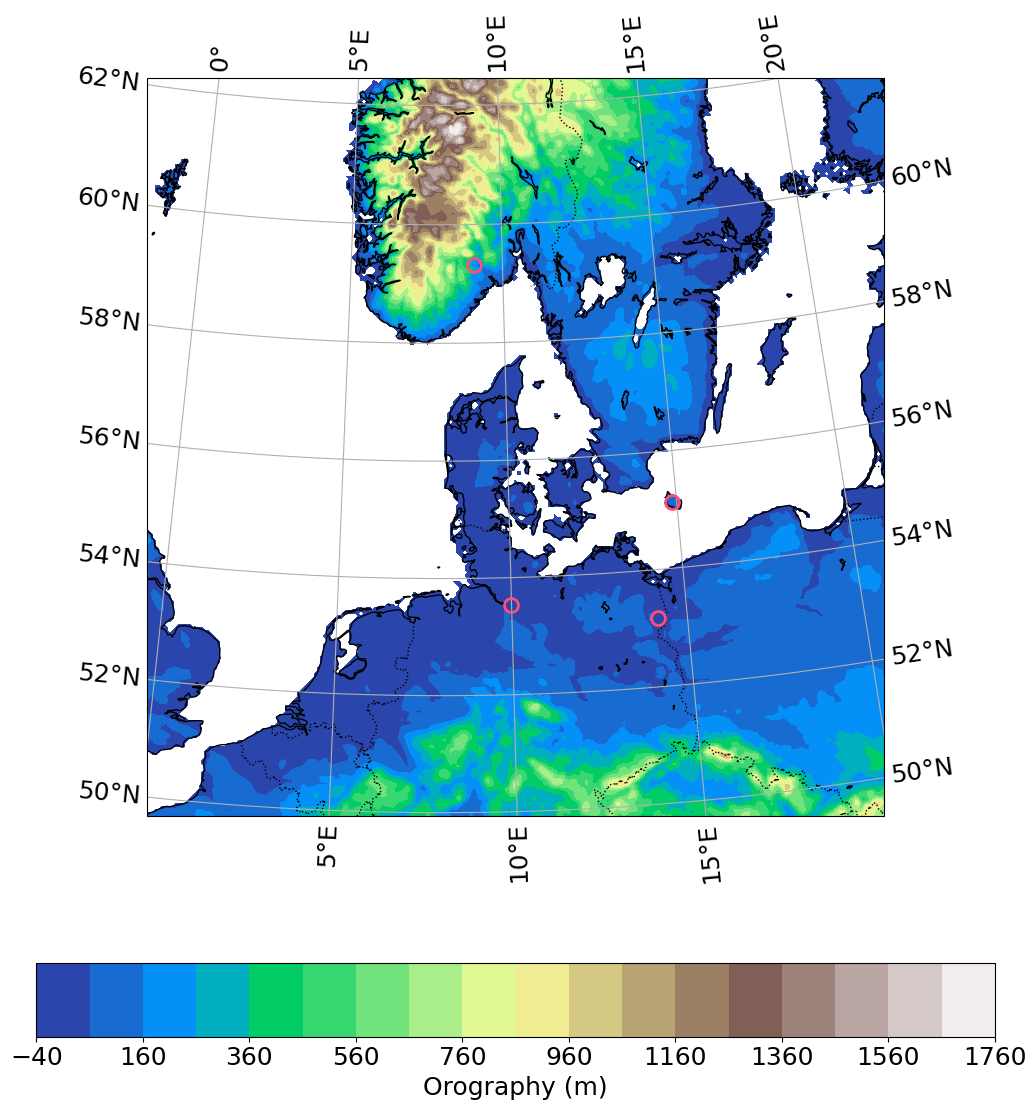

In [6]:
# Load orography data
orog = xr.open_dataset('../data/CERRA-ERA5/cerra_const_sfc_variables.nc4c', engine='netcdf4')['orog']

# If comparing with Swin2SR, crop the spatial dimensions of orog
if compare_w_swin2sr:
    orog = orog[:, 40:215, 60:215]
    orog = xr.where(s2sr.isel(time=0).expand_dims({'time':orog.time}).isnull(), np.nan, orog)

# If comparing with a model that does sea-masking, apply sea mask
if sea_masking:
    border_color = 'k'
    orog = xr.where(lsm < .01, np.nan, orog)
else:
    border_color = 'white'

# Projection and coordinates
transformer = Transformer.from_crs(
   "EPSG:4326",  # WGS84 lon/lat
   "+proj=lcc +lat_0=50 +lon_0=8 +lat_1=50 +lat_2=50 +R=6371229 +units=m",
   always_xy=True
)

lon0 = ds['Lambert_Conformal'].attrs['longitudeOfFirstGridPointInDegrees']
lat0 = ds['Lambert_Conformal'].attrs['latitudeOfFirstGridPointInDegrees']

x0, y0 = transformer.transform(lon0, lat0)

lambert_proj = ccrs.LambertConformal(
   central_longitude=8,
   central_latitude=50,
   standard_parallels=(50, 50),
   globe=ccrs.Globe(ellipse='sphere', semimajor_axis=6371229.0),
   false_easting=-x0,
   false_northing=-y0
)

x = orog.x
y = orog.y

# Create figure with map projection
fig, ax = plt.subplots(figsize=(12, 12), subplot_kw={'projection': lambert_proj})

# Plot the data
pcm = ax.contourf(x, y,
                  orog[0,:,:],   
                  levels=range(int(orog[0,:,:].min()/10)*10, int(orog[0,:,:].max()/10)*10, 100),  
                  cmap='terrain',
                  transform=lambert_proj)

# Add map features
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
ax.coastlines(color=border_color)
ax.add_feature(cartopy.feature.BORDERS, ec=border_color, linestyle=':')
ax.add_feature(cartopy.feature.LAKES, fc='#00000000', ec=border_color) # type: ignore

# Add study points
for i in range(nb_points):
    x_pt, y_pt = transformer.transform(study_points['lon'][i], study_points['lat'][i])
    study_points.at[i, 'x'] = x_pt-x0
    study_points.at[i, 'y'] = y_pt

ax.scatter(study_points['x'], study_points['y'],
         fc='#00000000', s=100, marker='o', lw=2, ec="#FF4F78",
         transform=lambert_proj, zorder=10)

# Add colorbar
cax = ax.inset_axes((-.15, -.3, 1.3, .1))
plt.colorbar(pcm, cax = cax, orientation="horizontal", label='Orography (m)')

# Add title
# plt.title(f'CERRA Orography and study points')

plt.tight_layout()
plt.show()

In [7]:
name_models

['Baseline', 'Land', 'Weighted', 'Full']

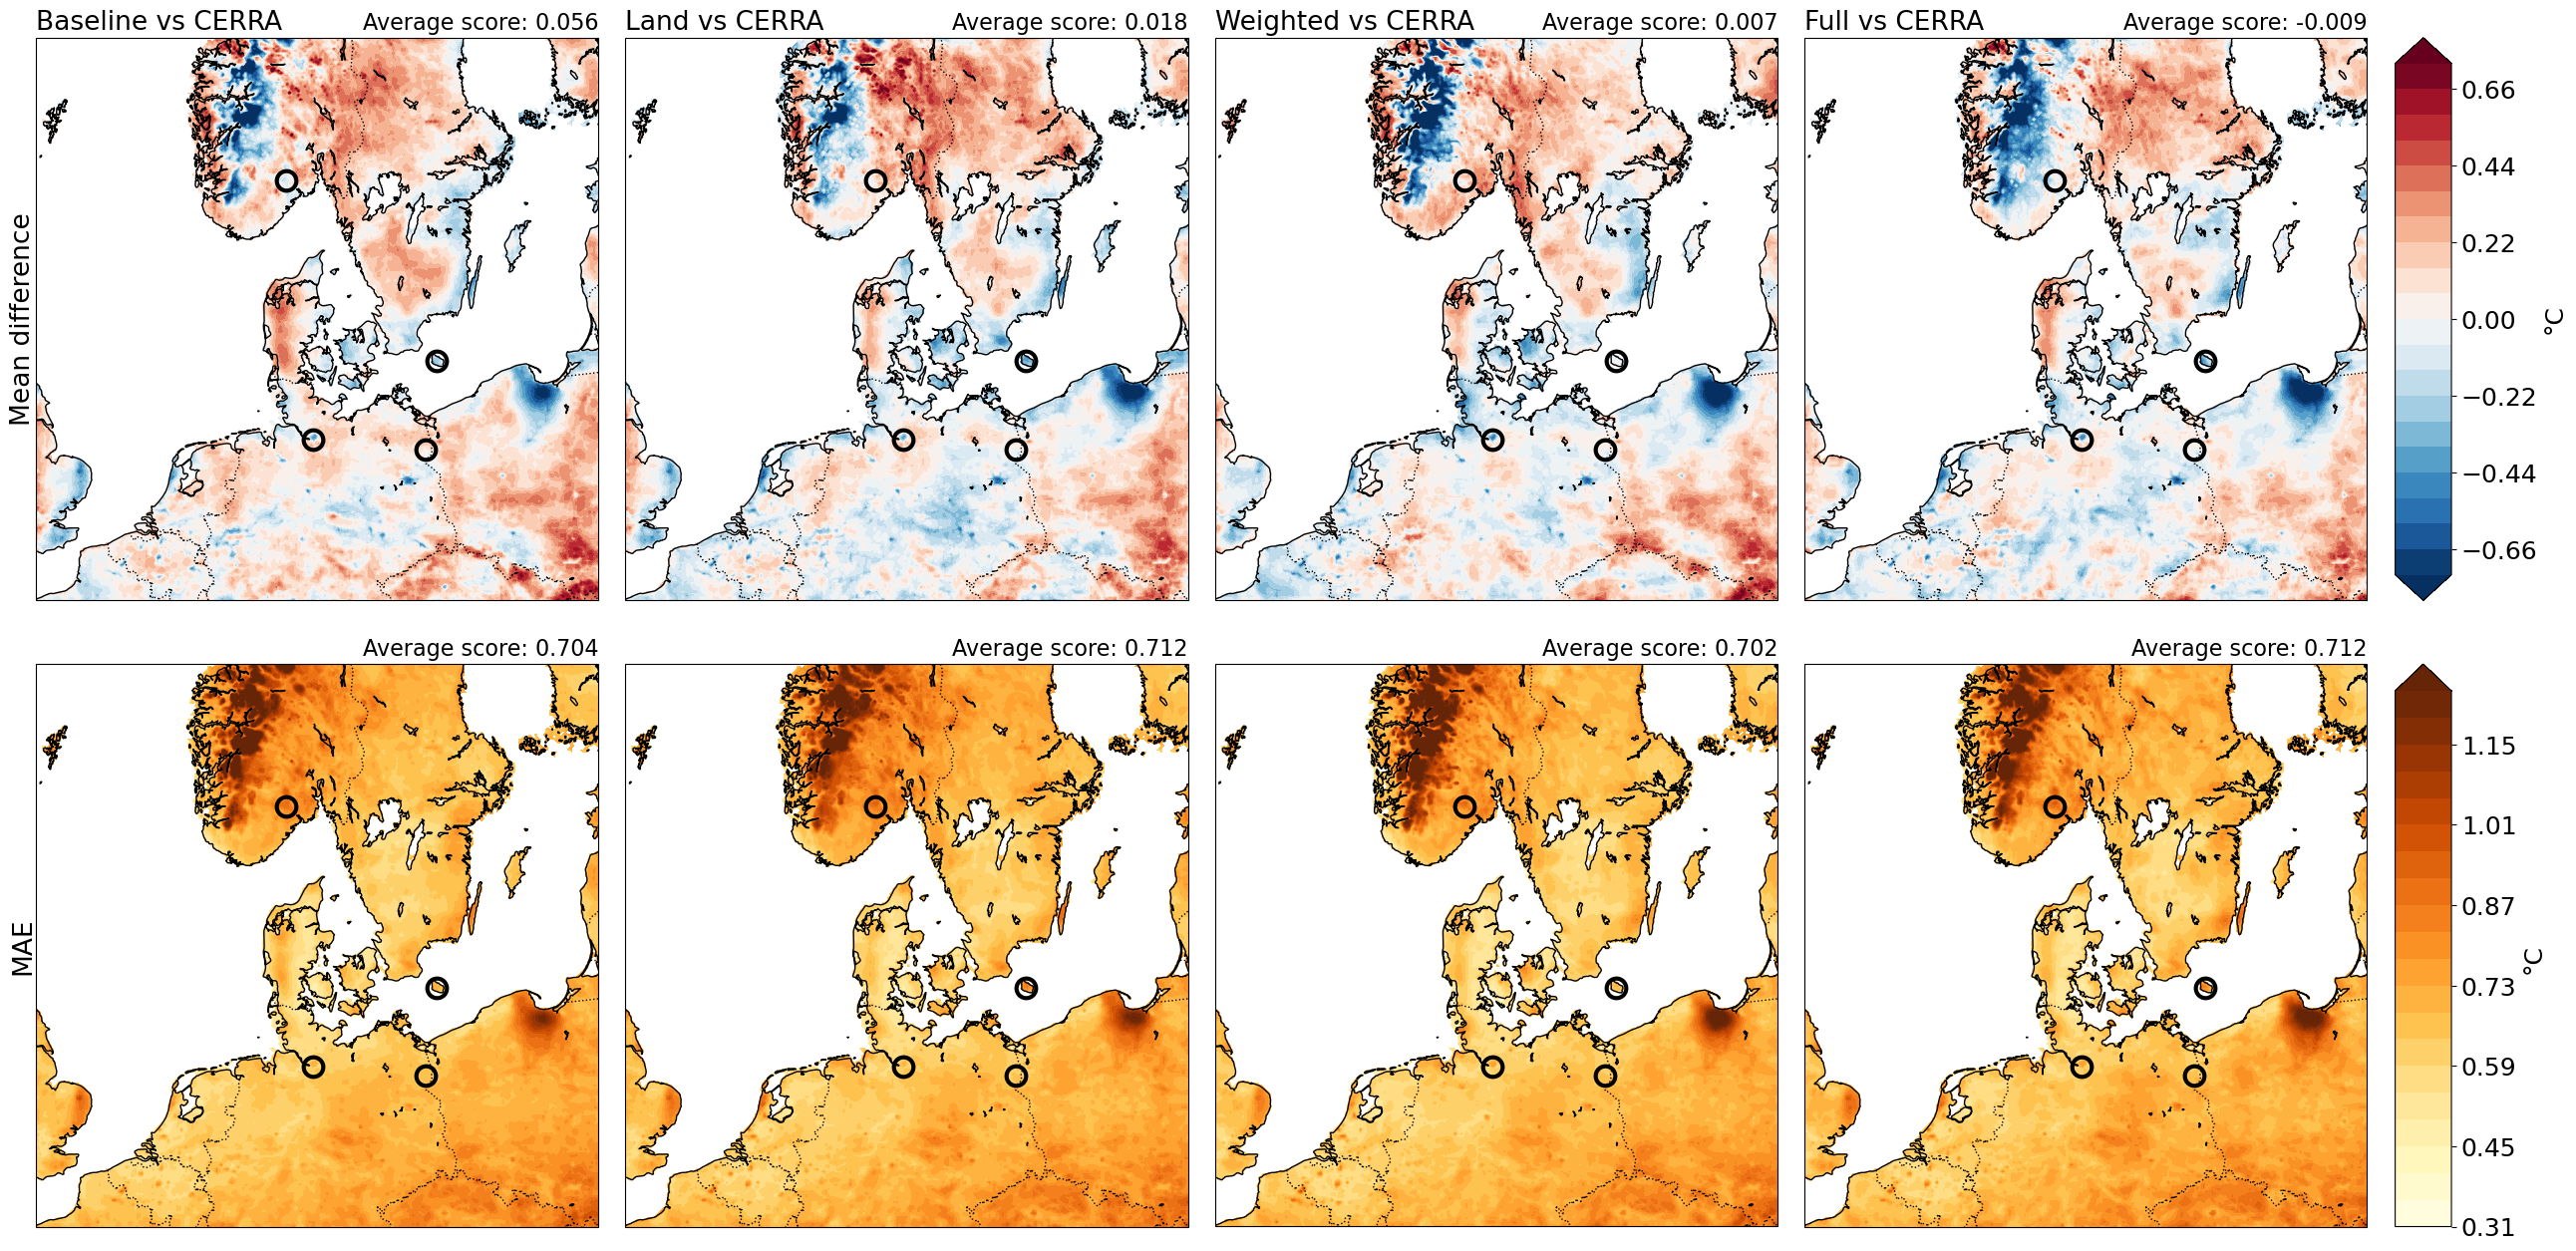

In [8]:
# Spatial metrics

map_diff = []
map_rmse = []
map_mae = []
for model in models:
    map_diff.append((model - truth).mean(dim='time'))
    # map_rmse.append(((model - truth)**2 ).mean(dim='time')**0.5)
    map_mae.append(np.abs(model - truth).mean(dim='time'))

map_diff = xr.concat(map_diff, dim='model')
# map_rmse = xr.concat(map_rmse, dim='model')
map_mae = xr.concat(map_mae, dim='model')

# map_metrics = xr.concat([map_diff, map_rmse, map_mae], dim='metric')
# name_metrics = ['Mean difference', 'RMSE', 'MAE']
map_metrics = xr.concat([map_diff, map_mae], dim='metric')
name_metrics = ['Mean difference', 'MAE']
nb_metrics = len(map_metrics)

# Plotting params
# cmaps = ["RdBu_r", "YlOrBr", "YlOrBr"]
cmaps = ["RdBu_r", "YlOrBr"]
plot_varnames = ["Temperature"]
plot_var_labels = ["°C"]

fig, axs = plt.subplots(nb_metrics, nb_models, figsize=(nb_models * 6.5, nb_metrics * 6.5),
                         subplot_kw={'projection': lambert_proj})

for i in range(nb_metrics):
    axs[i, 0].text(0, .5, f'{name_metrics[i]}', transform=axs[i, 0].transAxes,
                rotation='vertical', ha='right', va='center', fontsize=19)
    
    # Color scheme: centered for mean difference, fitted for others
    if i == 0:
        vmax = max(map_metrics[i,:,:].quantile(0.99), abs(map_metrics[i,:,:].quantile(0.01)))
        vmin = -vmax
    else:
        vmax = map_metrics[i,:,:].quantile(0.99)
        vmin = map_metrics[i,:,:].min()
    levels = np.linspace(vmin.item(), vmax.item(), 21)

    pcms = [[] for _ in range(nb_models)]
    for j in range(nb_models):
        axs[0, j].set_title(f'{name_models[j]} vs {name_truth}', loc='left', fontsize=19)
        ax = axs[i, j]
        pcms[j] = ax.contourf(map_metrics[i][j]['x'], map_metrics[i][j]['y'], map_metrics[i][j],
                            extend='both' if i == 0 else 'max',
                            cmap=cmaps[i], levels=levels, transform=lambert_proj)
        ax.coastlines()
        ax.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none') # type: ignore
        ax.add_feature(cartopy.feature.BORDERS, linestyle=':') # type: ignore
        score = map_metrics[i][j].mean().values # if i == 0 else map_metrics[i][j].quantile(.5, skipna=True).values
        score_name = 'Average' # if i == 0 else 'Median'
        ax.set_title(f'{score_name} score: {score:.3f}', loc='right', fontsize=16)
        ax.scatter(study_points['x'], study_points['y'],
         fc='#00000000', s=200, marker='o', lw=3, ec="k",
         transform=lambert_proj, zorder=10)
    cax = axs[i,-1].inset_axes([1.05, 0., .1, 1.])
    cbar = plt.colorbar(pcms[0], cax = cax, orientation="vertical", label=f"{plot_var_labels[0]}")
    cbar.ax.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:.2f}"))

plt.tight_layout()
plt.show()

In [9]:
regions_path = '../data/regions/regions.shp'

reader = cartopy.io.shapereader.Reader(regions_path)

regions = list(reader.geometries())
levels = range(int(vmin), int(vmax)+1, 3)
REGIONS = cartopy.feature.ShapelyFeature(regions, ccrs.epsg(3035))

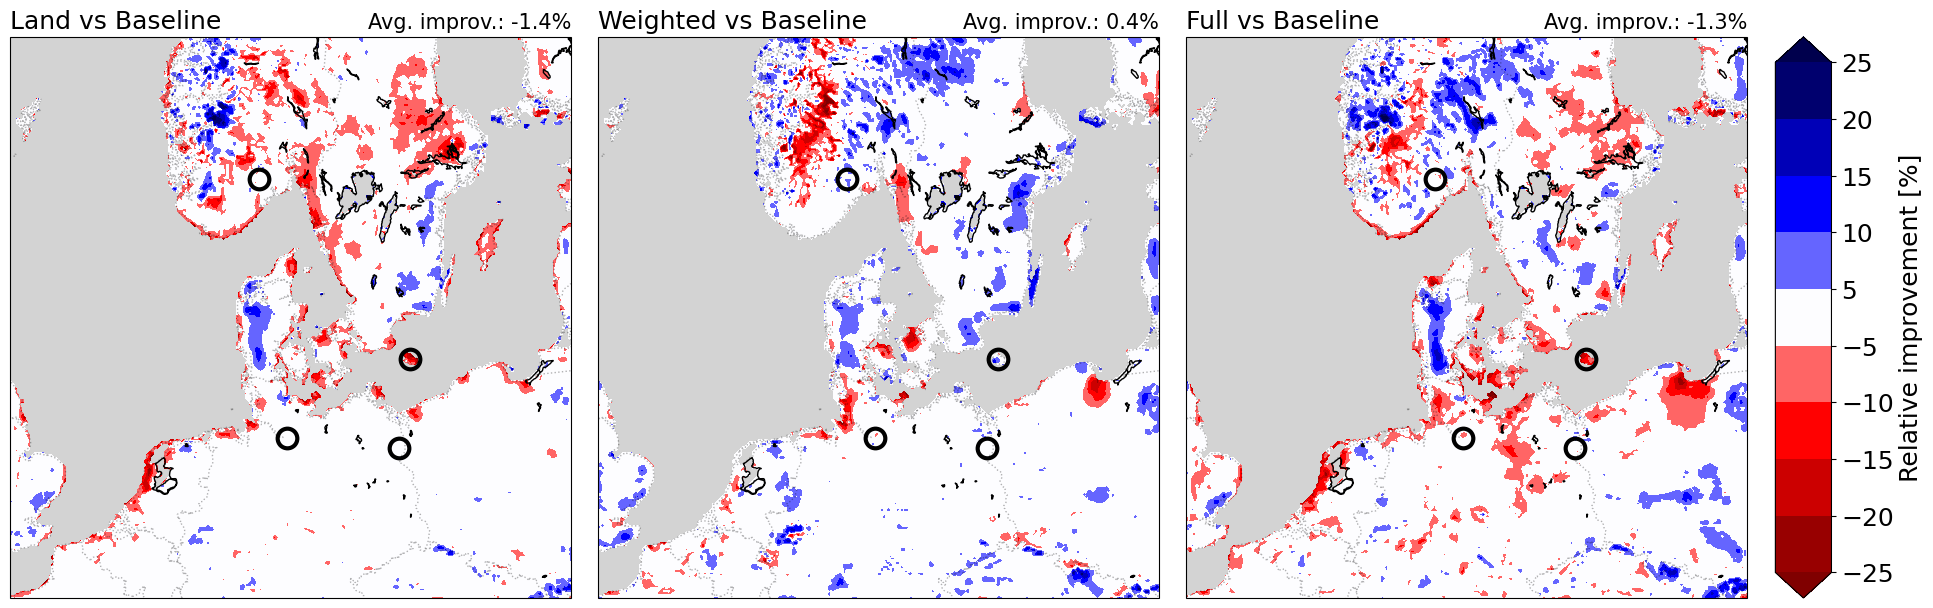

In [10]:
# Compute differences with baseline model
baseline_mae = map_mae[0]
delta_mae = []
for j in range(1, nb_models):
    delta_mae.append((baseline_mae - map_mae[j])/baseline_mae * 100)
#vmax = max(max([d.max() for d in delta_mae]), abs(min([d.min() for d in delta_mae])))
#vmin = -vmax
#level_nbr = 10
levels = np.concatenate([np.arange(-25, 0, 5), np.arange(5, 30, 5)]) 

fig, axs = plt.subplots(1, nb_models-1, figsize=((nb_models-1) * 6.5, 6.5),
                        subplot_kw={'projection': lambert_proj})
for j in range(1, nb_models):
    ax = axs[j-1]
    ax.set_facecolor('lightgray')
    pcm = ax.contourf(delta_mae[j-1]['x'], delta_mae[j-1]['y'], delta_mae[j-1], extend='both',
                        cmap=matplotlib.colormaps['seismic'].reversed(), levels=levels, transform=lambert_proj)
    ax.coastlines(ls=':', alpha=.3)
    #ax.add_feature(REGIONS, edgecolor='lightgray', facecolor='none', alpha=.5)
    ax.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none') # type: ignore
    ax.add_feature(cartopy.feature.BORDERS, linestyle=':', alpha=.3) # type: ignore
    score = delta_mae[j-1].mean().values
    ax.set_title(f'{name_models[j]} vs {name_models[0]}', loc='left', fontsize=18)
    ax.set_title(f'Avg. improv.: {score:.1f}%', loc='right', fontsize=15)
    ax.scatter(study_points['x'], study_points['y'],
        fc='#00000000', s=200, marker='o', lw=3, ec="k",
        transform=lambert_proj, zorder=10)
# Add colorbar
cax = axs[-1].inset_axes([1.05, 0., .1, 1.])
cbar = plt.colorbar(pcm, cax = cax, orientation="vertical", label=f"Relative improvement [%]")
cbar.ax.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
ticks = np.concatenate([np.arange(-25, 0, 5), np.arange(5, 30, 5)]) 
cbar.set_ticks(ticks)

plt.tight_layout()
plt.show()

### For one timestep

In [11]:
# Timestep
# t = '27-07-2018' # Among warmest
t = '15-05-2018'
truth_t = truth.sel(time=t)
models_t = [model.sel(time=t) for model in models]

In [12]:
len(models_t)

4

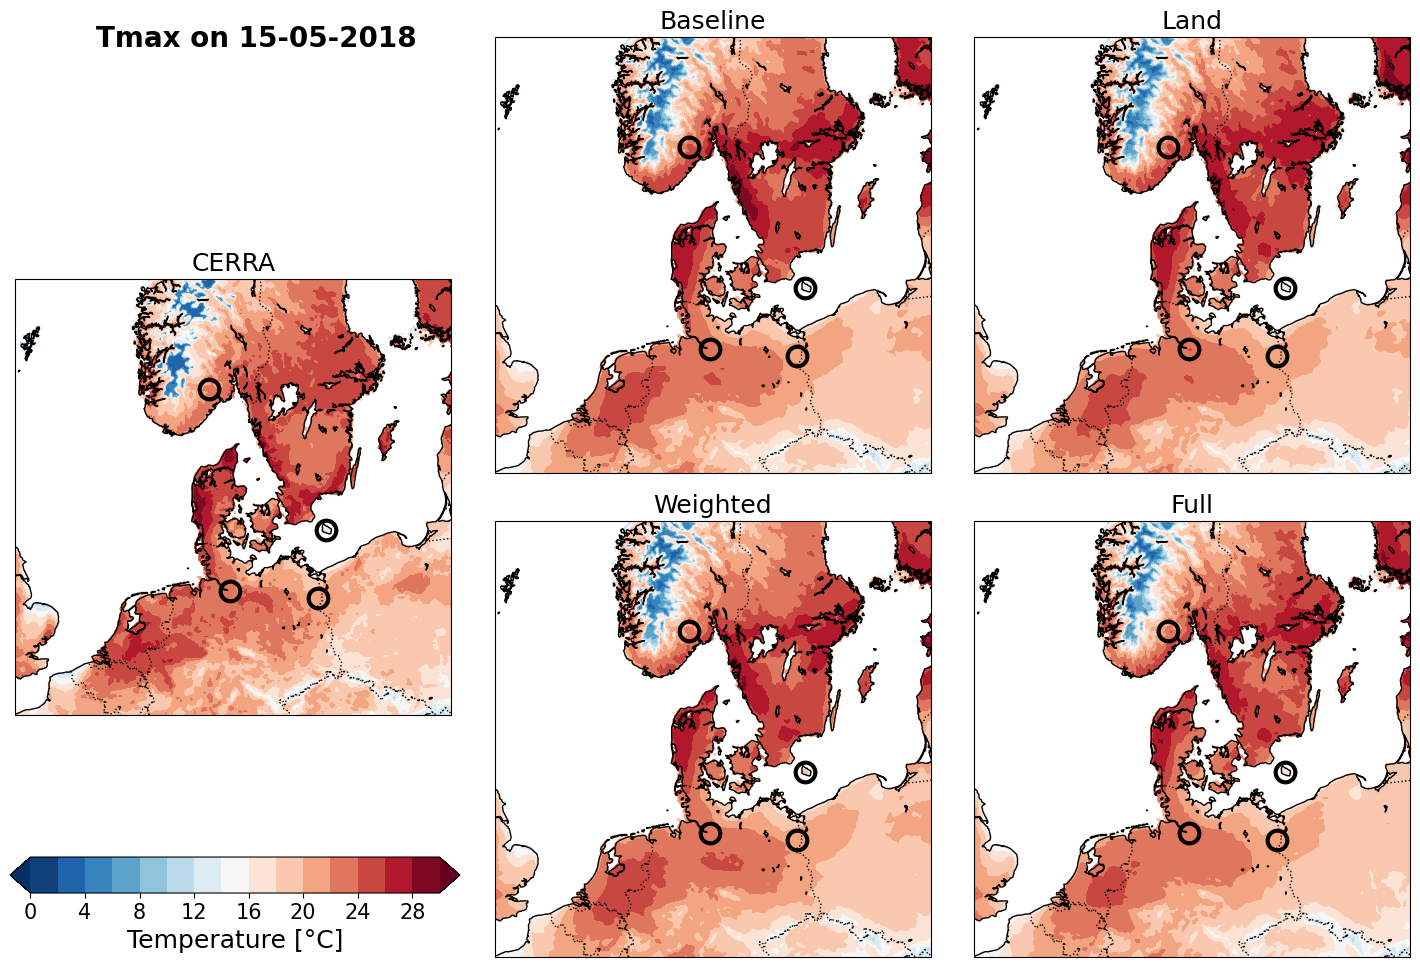

In [13]:
## HORIZONTAL LAYOUT

fig, axs = plt.subplots(2, 3, figsize=(3*6, 2*6), # Adjust by hand
                        subplot_kw={'projection': lambert_proj},
                        gridspec_kw={'wspace': 0.1,
                                     'hspace': 0.1})

# Color scheme: fitted
vmax = 30
vmin = 0
levels = np.linspace(int(vmin), int(vmax), 16)

gs = axs[0, 0].get_gridspec()
for ax in axs[:,0]:
    ax.remove()
axbig = fig.add_subplot(gs[:, 0], projection=lambert_proj)
axbig.coastlines()
axbig.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none') # type: ignore
axbig.add_feature(cartopy.feature.BORDERS, linestyle=':') # type: ignore
pcm = axbig.contourf(truth_t.x, truth_t.y, truth_t,
                    levels=levels,
                    cmap='RdBu_r', transform=lambert_proj, extend='both')
axbig.set_title(f"{name_truth}", fontsize=18)
axbig.scatter(study_points['x'], study_points['y'],
        fc='#00000000', s=200, marker='o', lw=3, ec="k",
        transform=lambert_proj, zorder=10)

for i in range(nb_models):
    ax = axs[i // 2, 1 + i%2]
    ax.coastlines()
    ax.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none') # type: ignore
    ax.add_feature(cartopy.feature.BORDERS, linestyle=':') # type: ignore
    pcm = ax.contourf(models_t[0].x, models_t[0].y, models_t[i],
                      levels=levels,
                      cmap='RdBu_r', transform=lambert_proj, extend='both')
    ax.set_title(f"{name_models[i]}", fontsize=18)
    ax.scatter(study_points['x'], study_points['y'],
         fc='#00000000', s=200, marker='o', lw=3, ec="k",
         transform=lambert_proj, zorder=10)

cax = fig.add_axes((.122, .165, .25, 0.03))
cbar = plt.colorbar(pcm, cax = cax, orientation="horizontal")
cbar.ax.tick_params(labelsize=15)
cbar.set_label(f"Temperature [°C]", fontsize=18)
fig.text(s=f'Tmax on {t}', x=.17, y=.87, fontsize=20, fontweight='bold')

plt.show()

### HW detection

In [14]:
thresholds = xr.open_dataarray(data_path + 'thresholds.nc4c', engine='netcdf4')

truth_hw = xr.where(truth >= thresholds, truth, 0)
for i in range(nb_models):
    models[i] = xr.where(models[i] >= thresholds, models[i], 0)

models = [truth_hw] + models
name_models = [name_truth] + name_models
color_models = [color_truth] + color_models

nb_models = len(models)

# Colorbar (HW)
vmax = truth_hw.max()
vmin = thresholds.min()

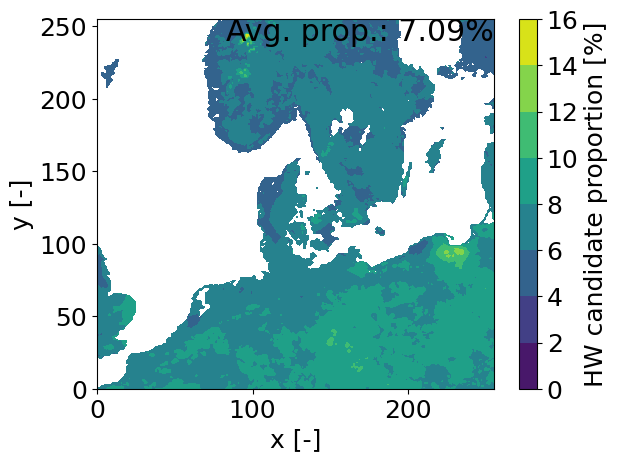

In [15]:
truth_hw_mask = models[0] > 0
truth_hw_mask_masked = xr.where(lsm.squeeze().expand_dims({'time': truth.time}) < .01, np.nan, truth_hw_mask) if sea_masking else truth_hw_mask
plt.contourf(truth_hw_mask_masked.mean(dim='time')*100, levels=range(0,18,2))
plt.xlabel('x [-]')
plt.ylabel('y [-]')
plt.title(f'Avg. prop.: {truth_hw_mask_masked.mean().values*100:.2f}%', loc='right', y=.92)
plt.colorbar(label='HW candidate proportion [%]')

In [16]:
def filter_shorter(data_array, min_consecutive=3):
    
    is_positive = (data_array > 0).values
    result = data_array.copy()
    
    # Use convolution to count consecutive positives
    # For each position, we'll check if it's part of a valid run
    valid_mask = np.zeros_like(is_positive, dtype=bool)
    
    for t in range(len(data_array.time)):
        # Check forward from this position
        end_t = min(t + min_consecutive, len(data_array.time))
        if np.all(is_positive[t:end_t], axis=0).any():
            # At least one location has enough consecutive values starting here
            for check_t in range(t, end_t):
                if check_t - t + 1 >= min_consecutive:
                    break
                window = is_positive[t:t+min_consecutive]
                if len(window) == min_consecutive:
                    valid_mask[t:t+min_consecutive] |= np.all(window, axis=0)
    
    result.values = np.where(valid_mask, result.values, 0)
    return result

for i in range(nb_models):
    models[i] = filter_shorter(models[i])
    if sea_masking:
        models[i] = xr.where(lsm.squeeze().expand_dims({'time': truth.time}) < .01, np.nan, models[i])

In [17]:
name_models

['CERRA', 'Baseline', 'Land', 'Weighted', 'Full']

Animating 4 timesteps from summer 2018


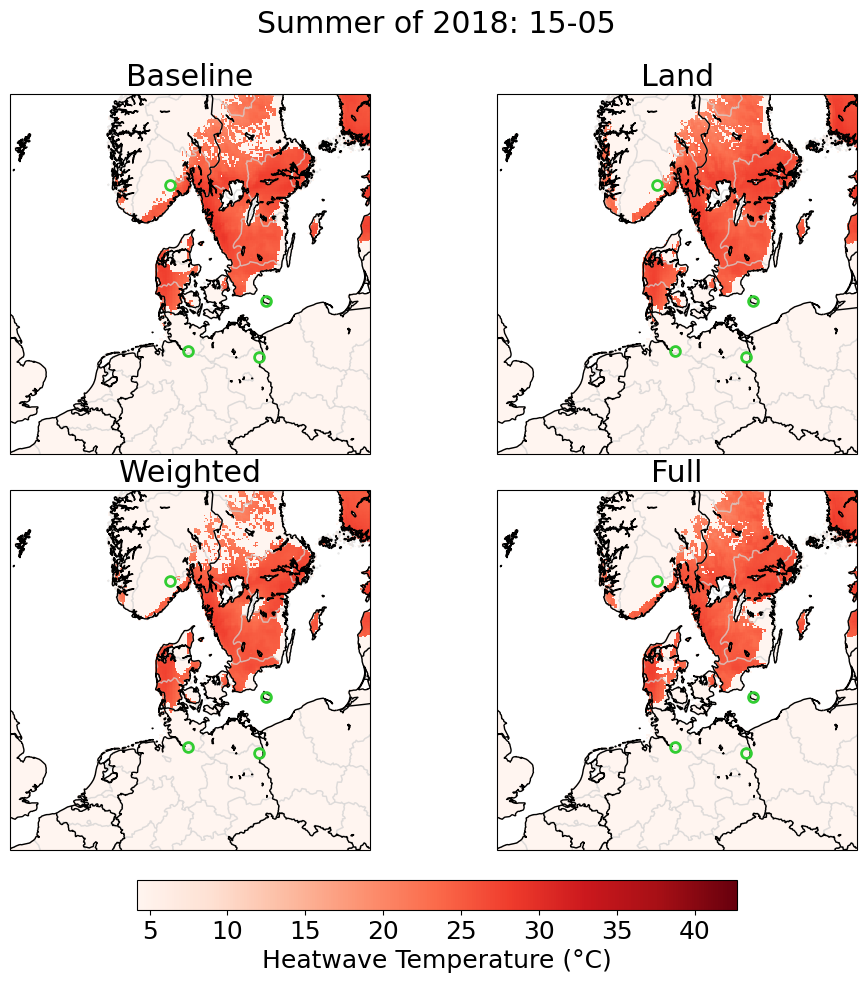

In [18]:
### CHOOSE YEAR HERE
year = 2018 # Between 2015 and 2020 incl.
summer_start = (datetime(year, 5, 15) - datetime(2015, 1, 1)).days
summer_end = (datetime(year, 9, 15) - datetime(2015, 1, 1)).days

summer_length = summer_end - summer_start + 1 - 120 # Comment -120 for full summer

print(f"Animating {summer_length} timesteps from summer {year}")

fig, axs = plt.subplots(nb_models//2, nb_models//2, figsize=(nb_models//2*6, nb_models//2*6), # Adjust by hand
                        subplot_kw={'projection': lambert_proj},
                        gridspec_kw={'wspace': 0.1,
                                     'hspace': 0.1})

x = models[0].x
y = models[0].y

# Create colorbar axis once
fig.subplots_adjust(bottom=0.25)
cax = fig.add_axes([.265, 0.2, .5, .025]) # type: ignore

# Define contour levels
# levels = range(int(vmin), int(vmax)+1, 3)

# Initialize plot elements
subplots = []

for i in range(1, nb_models):
    ax = axs[(i-1) // 2, (i-1) % 2]
    ax.add_feature(REGIONS, edgecolor='lightgray', facecolor='none', alpha=.5)
    ax.coastlines()
    ax.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none') # type: ignore
    ax.add_feature(cartopy.feature.BORDERS) # type: ignore
    
    # Initialize with first timestep
    model_t0 = models[i].isel(time=summer_start)
    subplot = ax.pcolormesh(x, y, model_t0,
                        vmin=vmin, vmax=vmax,
                        cmap='Reds', transform=lambert_proj)
    subplots.append(subplot)
    ax.scatter(study_points['x'], study_points['y'], 50, marker='o', fc='#00000000', ec='limegreen', lw=2, zorder=10)
    ax.set_title(f"{name_models[i]}")

# Add colorbar once
cbar = plt.colorbar(subplots[0], cax=cax, orientation="horizontal", 
                    label=f"Heatwave Temperature (°C)")

# Add a title to show current time
title = fig.suptitle(f'Summer of {year}: {pd.to_datetime(model_t0.time.values).strftime("%d-%m")}', x=.515, y=.95)

# Animation update function
def update(frame):
    t = cerra.time[summer_start + frame]
    title.set_text(f'Summer of {year}: {pd.to_datetime(t.values).strftime("%d-%m")}')
    
    for i in range(nb_models):
        
        model_t = models[i].sel(time=t)

        # ax = axs[i]
        # num_initial = 4  # coastlines, lakes, borders, regions
        # while len(ax.collections) > num_initial:
        #     ax.collections[-1].remove()
        # # Create new contours
        # ax.contourf(x, y, model_t, levels=levels,
        #                                vmin=vmin, vmax=vmax,
        #                                cmap='Reds', transform=lambert_proj)

        subplots[i-1].set_array(model_t.values.ravel())
    
    return []

# Create animation
anim = FuncAnimation(fig, update, frames=summer_length, 
                     interval=200, blit=False)

# Display in Jupyter notebook
HTML(anim.to_jshtml())

# Or save to file
# anim.save('temperature_animation.mp4', writer='ffmpeg', fps=5)
# anim.save(f'hw_summer_{year}.gif', writer='pillow', fps=5)

In [26]:
truth_hw_mask = models[0] > 0

confusion_maps = []
precision_maps = []
recall_maps = []
f1_maps = []
for model_number in range(1, nb_models):    
    print(f'Computing confusion map for {name_models[model_number]}')
    confusion_maps.append(xr.zeros_like(truth_hw))
    model_hw_mask = models[model_number] > 0
    fp = ~truth_hw_mask & model_hw_mask
    fn = truth_hw_mask & ~model_hw_mask
    tp = truth_hw_mask & model_hw_mask
    if sea_masking:
        fp = xr.where(lsm.squeeze().expand_dims({'time': truth.time}) < .01, np.nan, fp)
        fn = xr.where(lsm.squeeze().expand_dims({'time': truth.time}) < .01, np.nan, fn)
        tp = xr.where(lsm.squeeze().expand_dims({'time': truth.time}) < .01, np.nan, tp)
    confusion_maps[model_number-1] += xr.where(fp, 1, fp)
    confusion_maps[model_number-1] += xr.where(fn, 2, fn)
    confusion_maps[model_number-1] += xr.where(tp, 3, tp)
    confusion_maps[model_number-1] = xr.where( confusion_maps[model_number-1] == 6., np.nan, confusion_maps[model_number-1])
    print(f'TP: {float(tp.sum()/(~np.isnan(fp)).sum()):.3f} | FN: {float(fn.sum()/(~np.isnan(fp)).sum()):.3f}\n---------------------\nFP: {float(fp.sum()/(~np.isnan(fp)).sum()):.3f} | TN: {float(((~np.isnan(fp)).sum()-tp.sum()-fn.sum()-fp.sum())/(~np.isnan(fp)).sum()):.3f}')
    print(f'Precision: {float(tp.sum()/(tp.sum()+fp.sum())):.3f} | Recall/Sensitivity: {float(tp.sum()/(tp.sum()+fn.sum())):.3f}\nF1-score: {float(2*tp.sum()/(2*tp.sum()+fp.sum()+fn.sum())):.3f}')
    print('########\n')
    precision_map = tp.sum(dim='time') / (tp.sum(dim='time') + fp.sum(dim='time'))
    recall_map = tp.sum(dim='time') / (tp.sum(dim='time') + fn.sum(dim='time'))
    precision_maps.append(precision_map)
    recall_maps.append(recall_map)
    f1_maps.append((2*precision_map*recall_map/ (precision_map + recall_map)))

Computing confusion map for Baseline
TP: 0.039 | FN: 0.008
---------------------
FP: 0.007 | TN: 0.946
Precision: 0.854 | Recall/Sensitivity: 0.839
F1-score: 0.846
########

Computing confusion map for Land
TP: 0.040 | FN: 0.007
---------------------
FP: 0.007 | TN: 0.946
Precision: 0.851 | Recall/Sensitivity: 0.844
F1-score: 0.847
########

Computing confusion map for Weighted
TP: 0.039 | FN: 0.008
---------------------
FP: 0.007 | TN: 0.946
Precision: 0.857 | Recall/Sensitivity: 0.839
F1-score: 0.848
########

Computing confusion map for Full
TP: 0.038 | FN: 0.009
---------------------
FP: 0.005 | TN: 0.948
Precision: 0.881 | Recall/Sensitivity: 0.810
F1-score: 0.844
########



In [20]:
print(float(tp.sum()/(~np.isnan(fp)).sum()))
# fp.count()
print(2192*256*256)
float(tp.sum())


0.04017366458473485
143654912


3280172.0

In [ ]:
for y in range(2015, 2021):
    ### CHOOSE YEAR HERE
    year = y # Between 2015 and 2020 incl.
    summer_start = (datetime(year, 5, 15) - datetime(2015, 1, 1)).days
    summer_end = (datetime(year, 9, 15) - datetime(2015, 1, 1)).days

    summer_length = summer_end - summer_start + 1 -120 # Comment -120 for full summer

    print(f"Animating {summer_length} timesteps from summer {year}")

    # Create figure once
    fig, axs = plt.subplots(nb_models//2, nb_models//2, figsize=(nb_models//2*6, nb_models//2*6), # Adjust by hand
                            subplot_kw={'projection': lambert_proj})

    x = models[0].x
    y = models[0].y

    # Create colorbar axis once
    fig.subplots_adjust(bottom=0.25)
    cax = fig.add_axes([.265, 0.2, .5, .025]) # type: ignore

    # Create a custom colormap
    colors = ['#FFFFFF00', "#7AA8D3CC", "#EB6262CC", "#D113EEDD"]
    cmap = matplotlib.colors.ListedColormap(colors)
    cmap.set_bad(color='white')
    bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
    norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)
    custom_labels = ['TN', 'FP', 'FN', 'TP']

    pcms = []
    for model_number in range(1, nb_models):
        ax = axs[(model_number-1) // 2, (model_number-1) % 2]
        ax.add_feature(REGIONS, edgecolor='lightgray', facecolor='none', alpha=.5)
        ax.coastlines()
        ax.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none') # type: ignore
        ax.add_feature(cartopy.feature.BORDERS) # type: ignore

        # Initialize with first timestep
        cm_t0 = confusion_maps[model_number-1].isel(time=summer_start)
        pcms.append(ax.pcolormesh(x, y, cm_t0,
                    cmap=cmap, norm=norm, transform=lambert_proj))
        ax.scatter(study_points['x'], study_points['y'], 50, marker='o', fc='#00000000', ec='limegreen', lw=2, zorder=10)
        ax.set_title(f"{name_models[model_number]}", y=.9)

    # Add colorbar once
    cbar = plt.colorbar(pcms[0], cax=cax, orientation="horizontal", 
                        ticks=[0, 1, 2, 3], spacing='proportional')
    cbar.ax.set_xticklabels(custom_labels)
    cbar.set_label('Confusion Matrix')

    # Add a title to show current time
    title = fig.suptitle(f'Summer of {year}: {pd.to_datetime(model_t0.time.values).strftime("%d-%m")}', x=.515, y=.93)

    # Animation update function
    def update(frame):
        t = cerra.time[summer_start + frame]
        title.set_text(f'Summer of {year}: {pd.to_datetime(t.values).strftime("%d-%m")}')
        
        for model_number in range(1, nb_models):
            cm_t = confusion_maps[model_number-1].sel(time=t)
            pcms[model_number-1].set_array(cm_t.values.ravel())
        
        return []

    # Create animation
    anim = FuncAnimation(fig, update, frames=summer_length, 
                        interval=200, blit=False)

    # Display in Jupyter notebook
    # HTML(anim.to_jshtml())

    # Or save to file
    #anim.save(f'/dmidata/users/lucpar/MASTER_THESIS/report/figures/exps_hw_confusion_maps_{year}.gif', writer='pillow', fps=5)


### For demo points

In [22]:
to_date_str = lambda x : [str(np.datetime_as_string(x[i], unit='D')) for i in range(len(x))]

Full - City F1-score: 0.660
Full - Island F1-score: 0.455
Full - Plain F1-score: 0.655
Full - Valley F1-score: 0.847


<Figure size 640x480 with 0 Axes>

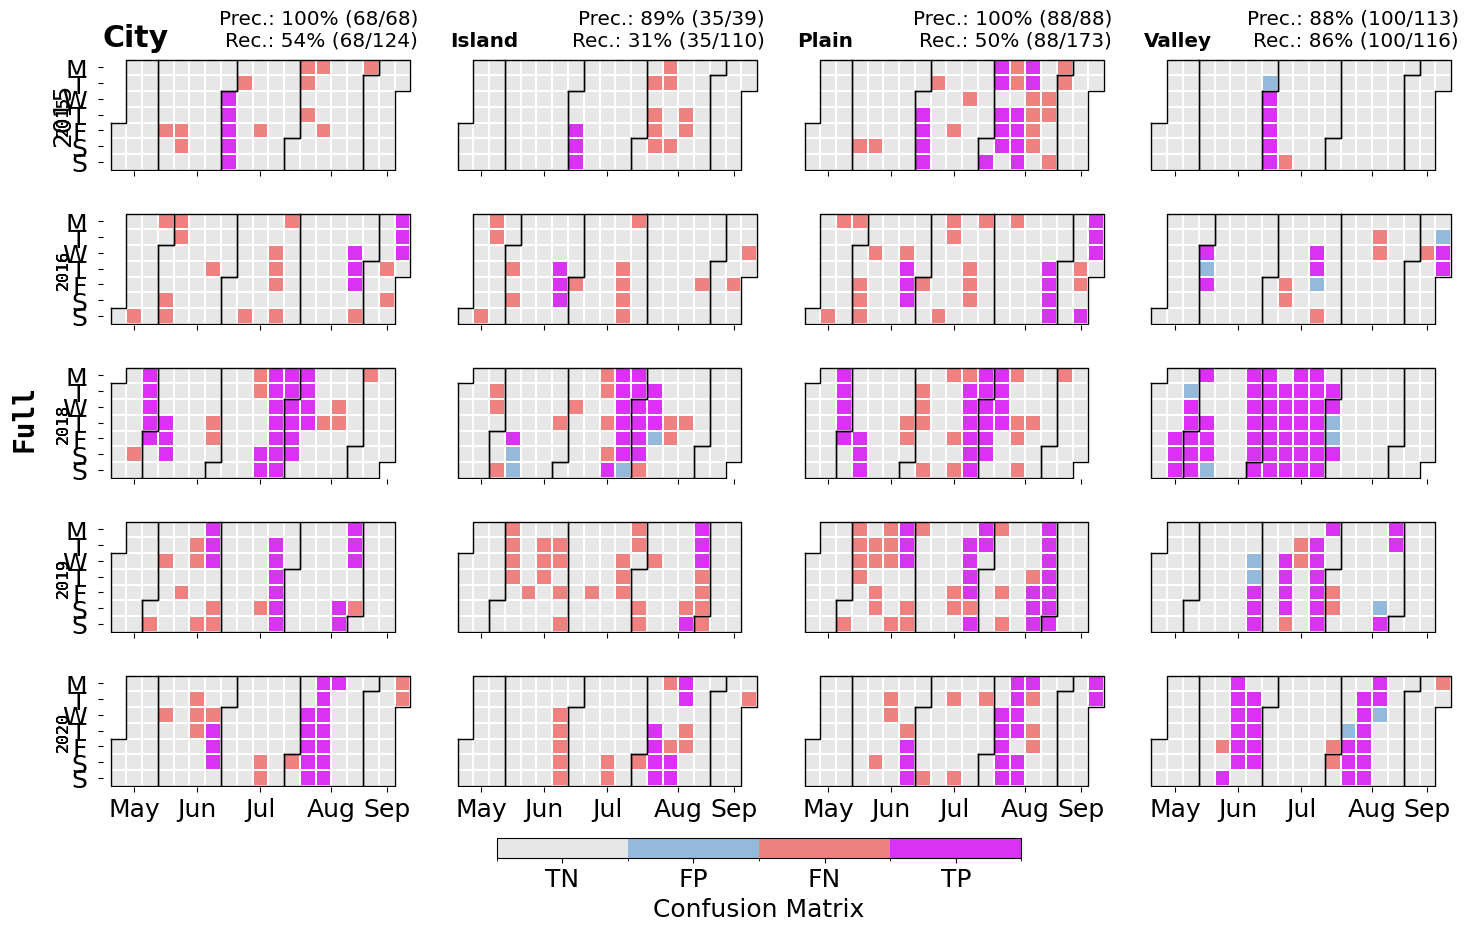

In [23]:
# needs to run twice for proper layout

### CHOOSE MODEL HERE
model_number = 4 # If compare_w_s2sr: 1 for ERA5, 2 for U-Net, 3 for Swin2SR

years = [2015, 2016, 2018, 2019, 2020] # No HW in 2017
nb_years = len(years)

plt.clf()
fig, axs = plt.subplots(nb_years, nb_points, figsize=(3.5*nb_years, 2.5*nb_points),
                        gridspec_kw={'wspace': 0.1, 'hspace': 0}, sharex='col')

# Create a custom colormap
colors = ['#CCCCCC77', "#7AA8D3CC", "#EB6262CC", "#D113EEDD"]
cmap = matplotlib.colors.ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)
custom_labels = ['TN', 'FP', 'FN', 'TP']
cax = fig.add_axes((.35, .06, .3, .02))
cbar = plt.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax, orientation="horizontal", 
                    ticks=[0, 1, 2, 3], spacing='proportional')
cbar.ax.set_xticklabels(custom_labels)
cbar.set_label('Confusion Matrix')

for j in range(nb_points):

    confusion_pt = confusion_maps[model_number-1].sel(x=study_points['x'][j], y=study_points['y'][j], method='nearest')
    fp = 0
    fn = 0
    tp = 0
    axs[0, j].set_title(study_points['feature'][j], y=1.1, loc='left', fontweight='bold')

    for i in range(nb_years):
        year = years[i]
        summer_start = (datetime(year, 5, 15) - datetime(2015, 1, 1)).days
        summer_end = (datetime(year, 9, 15) - datetime(2015, 1, 1)).days        
        fp += int((confusion_pt[summer_start:summer_end+1] == 1).sum())
        fn += int((confusion_pt[summer_start:summer_end+1] == 2).sum())
        tp += int((confusion_pt[summer_start:summer_end+1] == 3).sum())
        
        axs[i, 0].text(-3, 3.5, year, rotation='vertical', ha='center', va ='center')
        ax = axs[i, j]
        hm = july.heatmap(to_date_str(confusion_pt.time)[summer_start:summer_end+1], # type: ignore
                        confusion_pt[summer_start:summer_end+1],
                        ax=ax, cmap=cmap, cmin=0, cmax=3, month_label=i==nb_years-1, year_label=False, month_grid=True)
        if j > 0: ax.get_yaxis().set_visible(False)
    
    axs[0,j].set_title(f'Prec.: {int(100*tp/(tp+fp))}% ({tp}/{tp + fp})\nRec.: {int(100*tp/(tp + fn))}% ({tp}/{tp + fn})', y=1.1, pad=.3, loc='right') # These are for summer only
    print(f'{name_models[model_number]} - {study_points["feature"][j]} F1-score: {f1_maps[model_number-1].sel(x=study_points["x"][j], y=study_points["y"][j], method="nearest").values:.3f}') # This is for the whole test set

fig.text(0.08, 0.5, name_models[model_number], rotation='vertical', ha='center', va ='center', fontweight='bold', fontsize=20)

plt.show()


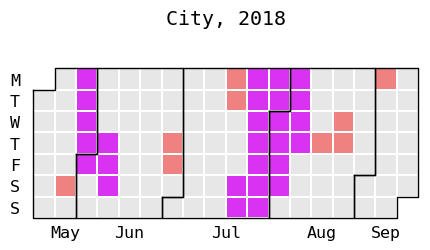

In [24]:
fig, ax = plt.subplots(figsize=(10, 2))
year = 2018
j = 0
model = 0
plt.title(f'{study_points["feature"][j]}, {year}')
summer_start = (datetime(year, 5, 15) - datetime(2015, 1, 1)).days
summer_end = (datetime(year, 9, 15) - datetime(2015, 1, 1)).days
hm = july.heatmap(to_date_str(confusion_maps[model].time)[summer_start:summer_end+1], # type: ignore
            confusion_maps[model].sel(x=study_points['x'][j], y=study_points['y'][j], method='nearest')[summer_start:summer_end+1],
            ax=ax, cmap=cmap, cmin=0, cmax=3, month_label=True, year_label=False, month_grid=True)

plt.show()

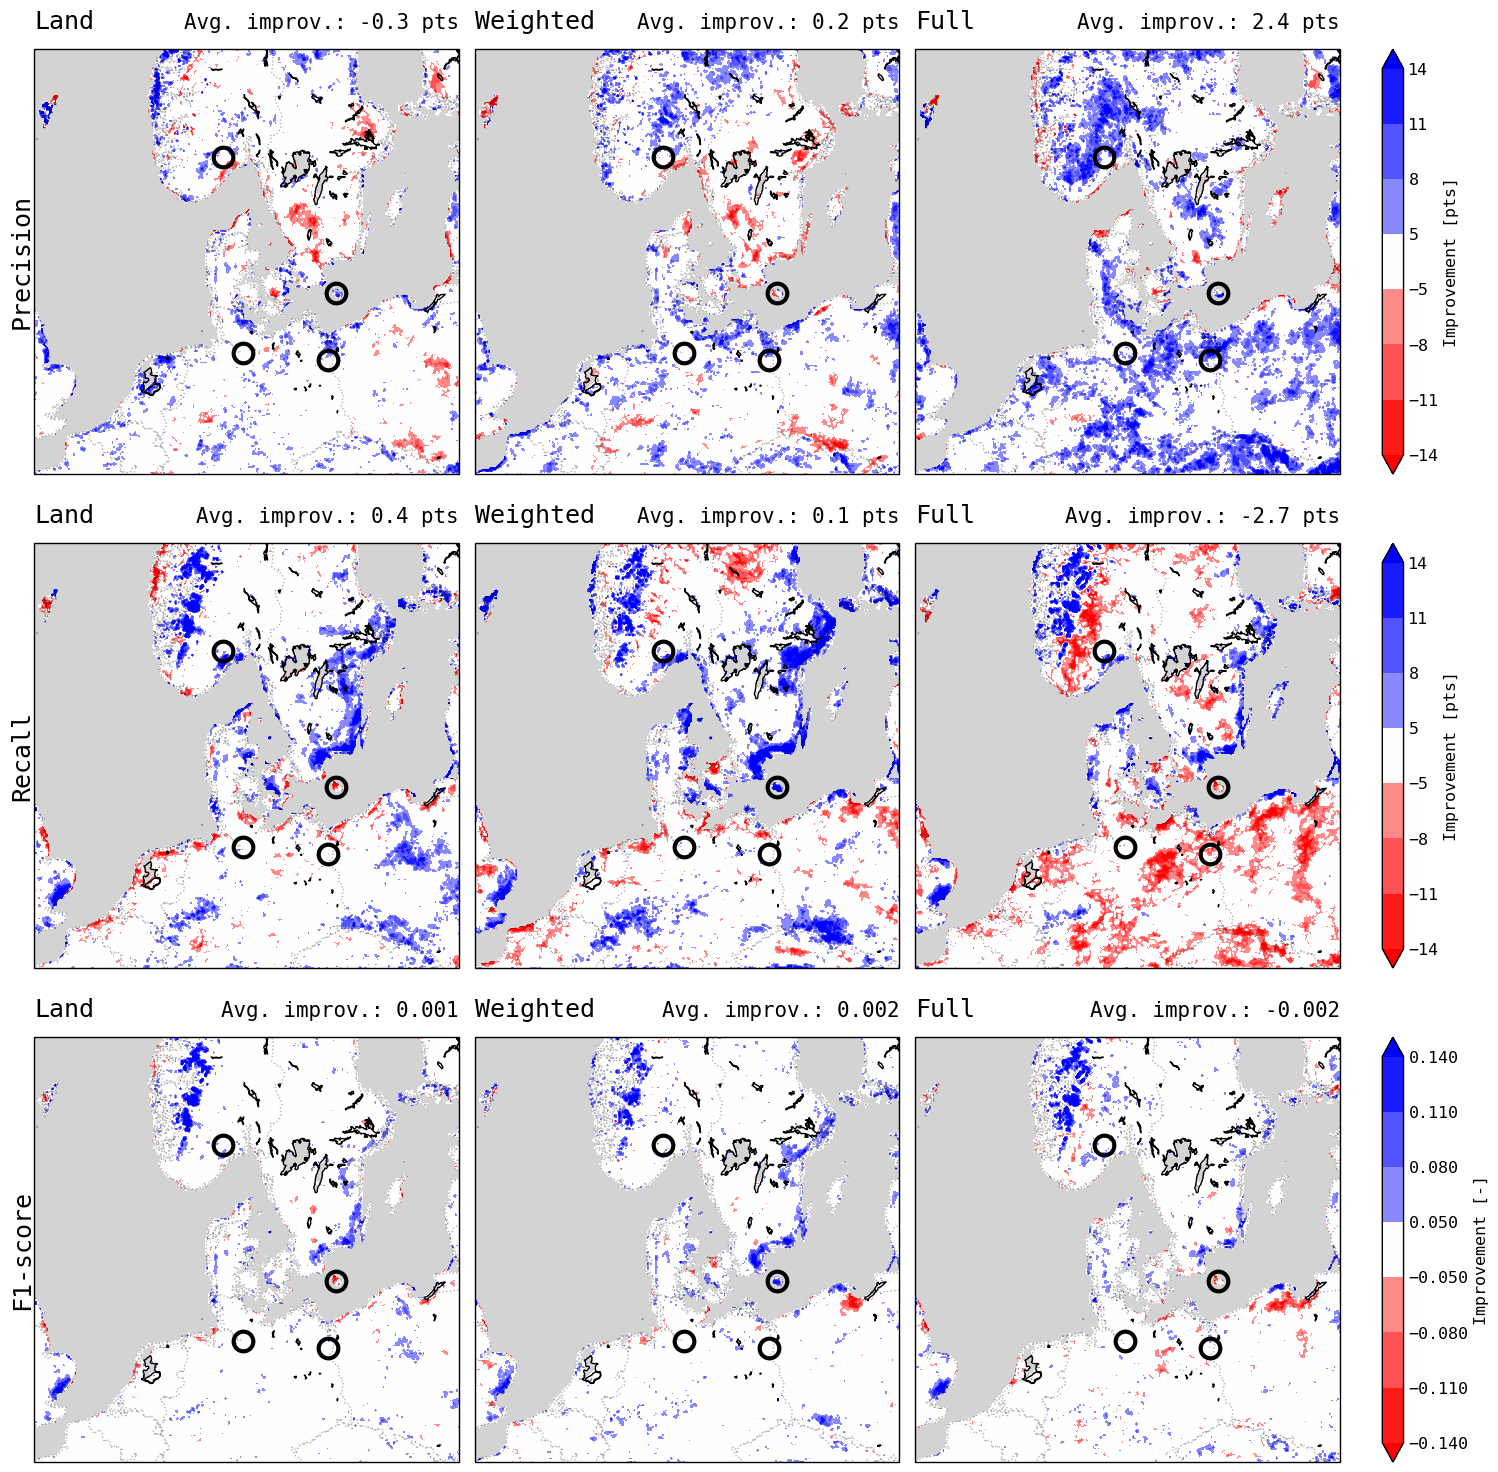

In [35]:
metric_maps = [precision_maps, recall_maps, f1_maps]
metric_names = ['Precision', 'Recall', 'F1-score']
nb_metrics = len(metric_maps)


if compare_w_swin2sr:
    # Display precision, recall and F1-score maps
    cmaps = ['Reds', 'Blues', 'Purples']

    levels = [np.linspace(50, 100, 11), np.linspace(50, 100, 11), np.linspace(.5, 1, 11)]

    fig, axs = plt.subplots(nb_metrics, nb_models-1, figsize=((nb_models-1) * 6, nb_metrics * 6),
                            subplot_kw={'projection': lambert_proj})

    for i in range(nb_metrics):

        axs[i, 0].text(0, .5, f'{metric_names[i]}', transform=axs[i, 0].transAxes,
                    rotation='vertical', ha='right', va='center', fontsize=18)

        for j in range(nb_models-1):
            
            ax = axs[i, j]
            pcm = ax.contourf(metric_maps[i][j]['x'], metric_maps[i][j]['y'], metric_maps[i][j]*100 if metric_names[i] != 'F1-score' else metric_maps[i][j],
                                cmap=cmaps[i], levels=levels[i], transform=lambert_proj, extend='min')
            ax.coastlines()
            ax.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none') # type: ignore
            ax.add_feature(cartopy.feature.BORDERS, linestyle=':', alpha=.3) # type: ignore
            score = metric_maps[i][j].mean().values*100 if metric_names[i] != 'F1-score' else metric_maps[i][j].mean().values
            ax.set_title(f'{name_models[j+1]}', loc='left', y=0.95, fontsize=18)
            ax.set_title(f'Avg. score: {score:.1f}%' if metric_names[i] != 'F1-score' else f'Avg. score: {score:.2f}', loc='right', y=0.95, fontsize=15)
            ax.scatter(study_points['x'], study_points['y'],
                fc='#00000000', s=200, marker='o', lw=3, ec="k",
                transform=lambert_proj, zorder=10)
            
        # Add colorbar
        cax = ax.inset_axes((1.1, 0, .05, 1))
        cbar = plt.colorbar(pcm, cax = cax, orientation="vertical", label='[%]' if metric_names[i] != 'F1-score' else '[-]')
        # cbar.ax.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:.0f}%"))

else:
    # Display improvement in precision, recall and F1-score maps
    levels = np.concatenate([np.arange(-14, -2, 3), np.arange(5, 15, 3)])/100

    fig, axs = plt.subplots(nb_metrics, nb_models-2, figsize=((nb_models-2) * 5, nb_metrics * 5),
                            subplot_kw={'projection': lambert_proj})

    for i in range(nb_metrics):

        axs[i, 0].text(0, .5, f'{metric_names[i]}', transform=axs[i, 0].transAxes,
                    rotation='vertical', ha='right', va='center', fontsize=18)
        
        baseline_score = metric_maps[i][0]

        for j in range(1, nb_models-1):
            
            ax = axs[i, j-1]
            ax.set_facecolor('lightgray')
            pcm = ax.contourf(metric_maps[i][j]['x'], metric_maps[i][j]['y'], (metric_maps[i][j]-baseline_score)*100 if metric_names[i] != 'F1-score' else (metric_maps[i][j]-baseline_score),
                                cmap=matplotlib.colormaps['bwr'].reversed(), levels=levels*100 if metric_names[i] != 'F1-score' else levels,transform=lambert_proj, extend='both')
            ax.coastlines(linestyle=':', alpha=.3)
            ax.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none') # type: ignore
            ax.add_feature(cartopy.feature.BORDERS, linestyle=':', alpha=.3) # type: ignore
            #ax.add_feature(REGIONS, edgecolor='k', facecolor='none')
            score = (metric_maps[i][j]-baseline_score).mean().values
            ax.set_title(f'{name_models[j+1]}', loc='left', y=0.95, fontsize=18)
            ax.set_title(f'Avg. improv.: {score*100:.1f} pts' if metric_names[i] != 'F1-score' else f'Avg. improv.: {score:.3f}', loc='right', y=0.95, fontsize=15)
            ax.scatter(study_points['x'], study_points['y'],
                fc='#00000000', s=200, marker='o', lw=3, ec="k",
                transform=lambert_proj, zorder=10)
            
        # Add colorbar
        cax = ax.inset_axes((1.1, 0, .05, 1))
        cbar = plt.colorbar(pcm, cax = cax, orientation="vertical", label='Improvement [pts]' if metric_names[i] != 'F1-score' else 'Improvement [-]')
        cbar.ax.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:.0f}")) if metric_names[i] != 'F1-score' else cbar.ax.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:.3f}"))
        ticks = levels*100 if metric_names[i] != 'F1-score' else levels
        cbar.set_ticks(ticks)

plt.tight_layout()
plt.show()

In [93]:
metric_maps[1][0].mean()

<xarray.DataArray ()> Size: 8B
array(0.8419493)
Coordinates:
    height    float64 8B 2.0
    quantile  float64 8B 0.95

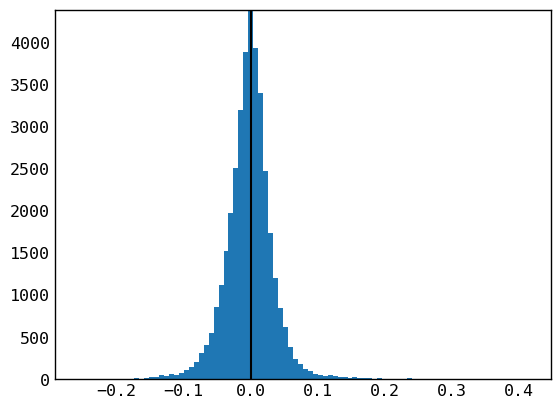

-0.29230769230769227 0.4482777564137779
-0.001702622036828461
0.02564114357844423


In [91]:
diff = (metric_maps[2][3] - metric_maps[2][0]).values.flatten()
diff = diff[~np.isnan(diff)]
plt.hist(diff, bins=100)
plt.axvline(0, color='k')
plt.show()
abs((metric_maps[2][3]-metric_maps[2][0])*100).mean()
diff = (metric_maps[2][3] - metric_maps[2][0])
print(diff.min().values, diff.max().values)
print(diff.mean().values)
print(abs(diff).mean().values)